# 11 - Streaming and Real-Time Processing

**Objective:** Implement IQ streaming, on-FPGA averaging, and real-time decimation. This notebook covers:
- Streaming mode for continuous IQ data capture
- On-FPGA averaging for noise reduction
- Real-time decimation to reduce data bandwidth
- Comparison of streaming vs. buffered readout modes

## 1. Setup

In [ ]:
# Standard imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import logging
from scipy import signal

from qick import *
from qick.asm_v2 import AveragerProgramV2

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s [%(filename)s:%(lineno)d] %(message)s')

# Connect to the board
BITSTREAM_PATH = '/path/to/your/firmware.bit'  # <--- CHANGE THIS
soc = QickSoc(BITSTREAM_PATH)
soccfg = soc

# Define hardware channels
GEN_CH = 0
RO_CH = 0

print("Ready")

Ready


## 2. Streaming Mode Overview

By default, the QICK captures readout data in **buffered mode**, where data is stored in on-board memory and transferred after the experiment. 

**Streaming mode** continuously streams IQ data from the ADC to the host computer in real-time. This is useful for:
- Monitoring signals over long periods
- Real-time feedback and decision making
- Capturing transient events
- High-throughput experiments

The trade-off: streaming generates large amounts of data and requires high-bandwidth communication.

## 3. Basic Streaming Example

Let's configure a simple streaming acquisition.

INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK


  0%|          | 0/1 [00:00<?, ?it/s]

INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP


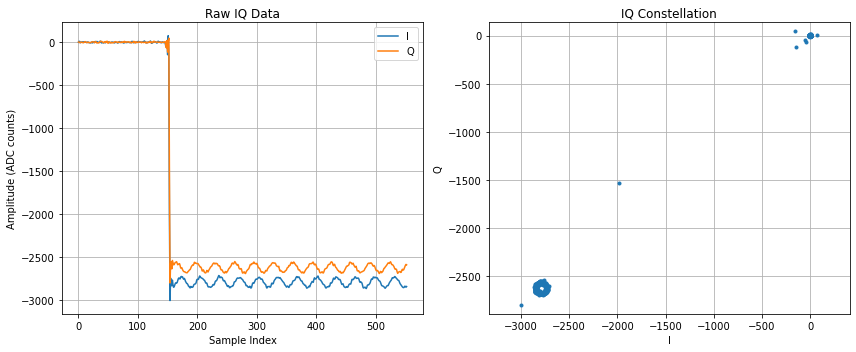

Total samples captured: 553


In [3]:
class StreamingProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['pulse_len'])
        
        self.add_pulse(
            ch=cfg['gen_ch'], name="test_pulse",
            style="const",
            freq=cfg['freq'], length=cfg['pulse_len'],
            phase=0, gain=cfg['gain']
        )
        self.add_readoutconfig(ch=cfg['ro_ch'], name="ro",
                               freq=cfg['freq'], gen_ch=cfg['gen_ch'])
        self.send_readoutconfig(ch=cfg['ro_ch'], name="ro", t=0)

    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="test_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=0.035)

config_stream = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500.0,
    'pulse_len': 1.0,
    'gain': 0.5,
}

prog = StreamingProgram(soccfg, reps=1, final_delay=0.5, cfg=config_stream)

# acquire_decimated returns the IQ samples over time.
iq_list = prog.acquire_decimated(soc, rounds=1)
# iq_list[ro_ch] tiene shape (samples, 2) -> columna 0=I, columna 1=Q
i_data = iq_list[0][:, 0]
q_data = iq_list[0][:, 1]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(i_data, label='I')
plt.plot(q_data, label='Q')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (ADC counts)')
plt.title('Raw IQ Data')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(i_data, q_data, '.')
plt.xlabel('I')
plt.ylabel('Q')
plt.title('IQ Constellation')
plt.axis('equal')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Total samples captured: {len(i_data)}")

## 4. Decimation in Streaming Mode

Decimation reduces the data rate by averaging or downsampling. This is crucial for long experiments where you don't need the full sample rate.

INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tpr

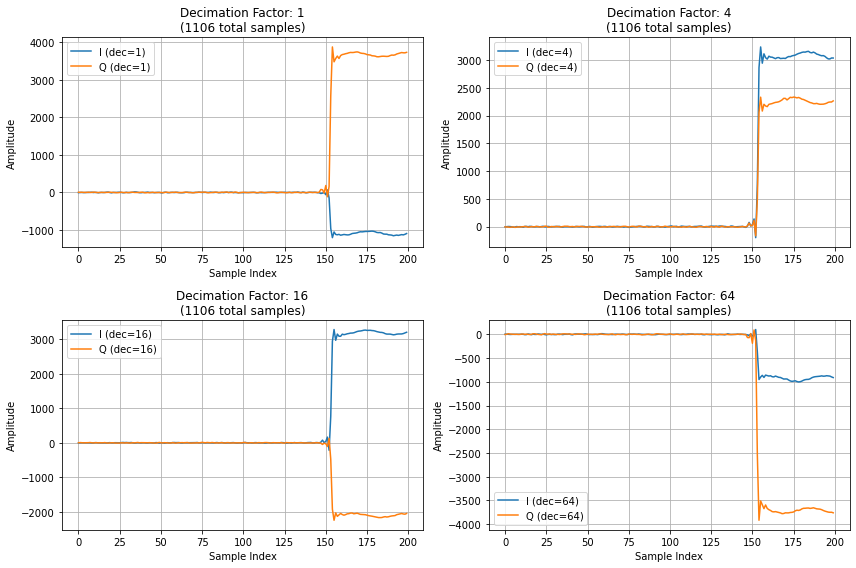

Decimation Summary:
  dec=1: 1106 samples
  dec=4: 1106 samples
  dec=16: 1106 samples
  dec=64: 1106 samples


In [4]:
decimations = [1, 4, 16, 64]
results = {}

for dec in decimations:
    config = config_stream.copy()
    config['pulse_len'] = 2.0

    prog = StreamingProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
    iq_list = prog.acquire_decimated(soc, rounds=1, progress=False)
    results[dec] = {
        'i': iq_list[0][:, 0],
        'q': iq_list[0][:, 1],
    }

plt.figure(figsize=(12, 8))
for idx, dec in enumerate(decimations):
    plt.subplot(2, 2, idx+1)
    data = results[dec]
    samples_to_plot = min(200, len(data['i']))
    plt.plot(data['i'][:samples_to_plot], label=f'I (dec={dec})')
    plt.plot(data['q'][:samples_to_plot], label=f'Q (dec={dec})')
    plt.xlabel('Sample Index')
    plt.ylabel('Amplitude')
    plt.title(f'Decimation Factor: {dec}\n({len(data["i"])} total samples)')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

print("Decimation Summary:")
for dec in decimations:
    print(f"  dec={dec}: {len(results[dec]['i'])} samples")

## 5. Real-Time Averaging

The QICK FPGA can perform on-the-fly averaging of multiple shots. This reduces noise without transferring all raw data to the host.

INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [t

Buffer: 16384 samples, ~2211 samples/rep -> max reps = 7
Usando reps=7, rounds=14


INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:

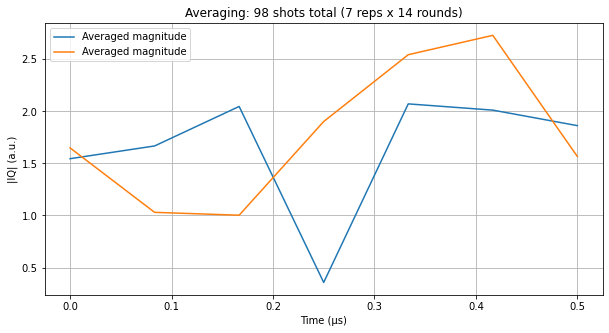

Data shape: (7, 276, 2)


In [5]:
class AveragingProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])
        
        self.add_pulse(ch=cfg['gen_ch'], name="test_pulse",
                       style="const",
                       freq=cfg['freq'], length=cfg['pulse_len'],
                       phase=0, gain=cfg['gain'])
        self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro",
                               freq=cfg['freq'], gen_ch=cfg['gen_ch'])
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.pulse(ch=cfg['gen_ch'], name="test_pulse", t=0)

config_avg = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500.0,
    'pulse_len': 0.3,
    'gain': 0.5,
    'trig_time': 0.05,
    'ro_len': 0.5,
    'avg_rounds': 100
}

# Calculate the maximum number of reps that fit in the buffer.
buf_maxlen = soccfg['readouts'][RO_CH]['buf_maxlen']
samples_per_rep = int(config_avg['ro_len'] * soccfg['readouts'][RO_CH]['fs'])  # aprox
max_reps = buf_maxlen // samples_per_rep
print(f"Buffer: {buf_maxlen} samples, ~{samples_per_rep} samples/rep -> max reps = {max_reps}")

# Option 1: Reduce reps, compensate with rounds (Python averages across multiple runs)
reps_per_round = min(config_avg['avg_rounds'], max_reps)
n_rounds = config_avg['avg_rounds'] // reps_per_round
print(f"Usando reps={reps_per_round}, rounds={n_rounds}")

prog = AveragingProgram(soccfg, reps=reps_per_round, final_delay=0.5, cfg=config_avg)
iq_avg = prog.acquire_decimated(soc, rounds=n_rounds, progress=False)

time_axis = np.linspace(0, config_avg['ro_len'], iq_avg[0].shape[0])

plt.figure(figsize=(10, 5))
plt.plot(time_axis, np.abs(iq_avg[0][:, 0] + 1j * iq_avg[0][:, 1]), label='Averaged magnitude')
plt.xlabel('Time (µs)')
plt.ylabel('|IQ| (a.u.)')
plt.title(f'Averaging: {reps_per_round * n_rounds} shots total ({reps_per_round} reps x {n_rounds} rounds)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Data shape: {iq_avg[0].shape}")

## 6. Streaming vs. Buffered Readout Comparison

Understanding the difference between streaming and buffered modes helps you choose the right approach for your experiment.

INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP


Buffer: 16384, samples/rep: 332, max_reps: 49


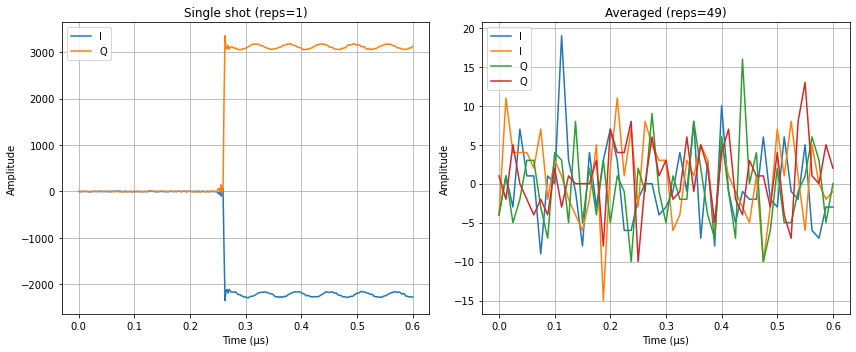

In [6]:
def compare_modes():
    
    class BufferCompare(AveragerProgramV2):
        def _initialize(self, cfg):
            self.declare_gen(ch=cfg['gen_ch'], nqz=1)
            self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])
            self.add_pulse(ch=cfg['gen_ch'], name="pulse",
                           style="const", freq=cfg['freq'],
                           length=cfg['pulse_len'], phase=0, gain=cfg['gain'])
            self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro",
                                   freq=cfg['freq'], gen_ch=cfg['gen_ch'])
            self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)

        def _body(self, cfg):
            self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
            self.pulse(ch=cfg['gen_ch'], name="pulse", t=0)

    common_config = {
        'gen_ch': GEN_CH,
        'ro_ch': RO_CH,
        'freq': 500.0,
        'pulse_len': 0.5,
        'gain': 0.5,
        'ro_len': 0.6,
        'trig_time': 0.05
    }

    # Calculate the maximum number of reps that fit in the buffer.
    buf_maxlen = soccfg['readouts'][RO_CH]['buf_maxlen']  # 16384
    samples_per_rep = 332  # some number less or equal than 332
    max_reps = buf_maxlen // samples_per_rep
    print(f"Buffer: {buf_maxlen}, samples/rep: {samples_per_rep}, max_reps: {max_reps}")

    # One rep (without avergaing)
    prog_single = BufferCompare(soccfg, reps=1, final_delay=0.5, cfg=common_config)
    iq_single = prog_single.acquire_decimated(soc, rounds=1, progress=False)

    # Máximos reps posibles (promediado)
    prog_avg = BufferCompare(soccfg, reps=max_reps, final_delay=0.5, cfg=common_config)
    iq_avg = prog_avg.acquire_decimated(soc, rounds=1, progress=False)

    time_single = np.linspace(0, common_config['ro_len'], iq_single[0].shape[0])
    time_avg    = np.linspace(0, common_config['ro_len'], iq_avg[0].shape[0])

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(time_single, iq_single[0][:, 0], label='I')
    plt.plot(time_single, iq_single[0][:, 1], label='Q')
    plt.xlabel('Time (µs)')
    plt.ylabel('Amplitude')
    plt.title('Single shot (reps=1)')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(time_avg, iq_avg[0][:, 0], label='I')
    plt.plot(time_avg, iq_avg[0][:, 1], label='Q')
    plt.xlabel('Time (µs)')
    plt.ylabel('Amplitude')
    plt.title(f'Averaged (reps={max_reps})')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return iq_single, iq_avg

single_data, avg_data = compare_modes()

## 7. Practical Application: Power Monitoring from Buffered Acquisition

Decimated readout data can be analyzed to estimate signal power and detect threshold crossings. 
This example demonstrates how to compute instantaneous power from IQ samples and identify events of interest.

INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP


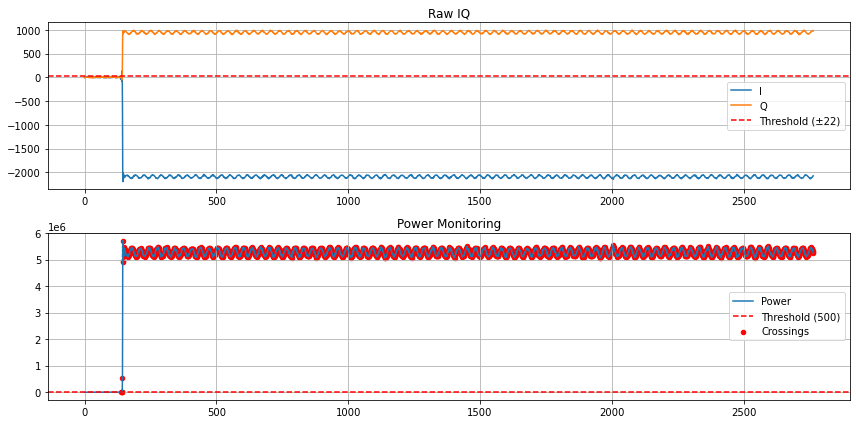

Samples: 2765
Crossings: 2625


In [7]:
def real_time_power_monitoring(threshold=1000, duration_ms=10):
    """
    Monitor signal power and detect when it exceeds a threshold.
    """

    class MonitorProgram(AveragerProgramV2):
        def _initialize(self, cfg):
            self.declare_gen(ch=cfg['gen_ch'], nqz=1)
            
            # Declare readout 
            self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])

            # Continuous Pulse (CW)
            self.add_pulse(
                ch=cfg['gen_ch'],
                name="cw_pulse",
                style="const",
                freq=cfg['freq'],
                length=cfg['pulse_len'],
                phase=0,
                gain=cfg['gain']
            )

            #  Configure readout
            self.add_readoutconfig(
                ch=cfg['ro_ch'],
                name="ro_cfg",
                freq=cfg['freq'],
                gen_ch=cfg['gen_ch']
            )

            self.send_readoutconfig(ch=cfg['ro_ch'], name="ro_cfg", t=0)

        def _body(self, cfg):
            # Acquisition trigger
            self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

            # CW Pulse
            self.pulse(ch=cfg['gen_ch'], name="cw_pulse", t=0)

    # Convert duration
    ro_len = duration_ms  # in µs (QICK uses µs)

    config = {
        'gen_ch': GEN_CH,
        'ro_ch': RO_CH,
        'freq': 500.0,
        'pulse_len': ro_len,
        'ro_len': ro_len,
        'gain': 0.3,
        'trig_time': 0.05
    }

    prog = MonitorProgram(soccfg, reps=1, final_delay=0.1, cfg=config)

    # Acquire data (correct way in V2)
    iq = prog.acquire_decimated(soc, rounds=1, progress=False)[0]

    i_data = iq[:, 0]
    q_data = iq[:, 1]

    # Potencia
    power = i_data**2 + q_data**2

    # Threshold
    threshold_crossings = np.where(power > threshold)[0]

    # Plot
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.plot(i_data, label='I')
    plt.plot(q_data, label='Q')
    plt.axhline(y=np.sqrt(threshold), color='r', linestyle='--',
                label=f'Threshold (±{np.sqrt(threshold):.0f})')
    plt.legend()
    plt.grid(True)
    plt.title('Raw IQ')

    plt.subplot(2, 1, 2)
    plt.plot(power, label='Power')
    plt.axhline(y=threshold, color='r', linestyle='--',
                label=f'Threshold ({threshold})')

    if len(threshold_crossings) > 0:
        plt.scatter(threshold_crossings,
                    power[threshold_crossings],
                    color='r', s=20, label='Crossings')

    plt.legend()
    plt.grid(True)
    plt.title('Power Monitoring')

    plt.tight_layout()
    plt.show()

    print(f"Samples: {len(power)}")
    print(f"Crossings: {len(threshold_crossings)}")

    return power, threshold_crossings


# Execute
power, crossings = real_time_power_monitoring(threshold=500, duration_ms=5)

## 8. Summary

You have learned:

* How to acquire IQ data using buffered (decimated) readout
* How decimation reduces data rate while preserving signal information
* How on-FPGA averaging reduces noise without host involvement
* The trade-offs between buffered acquisition and streaming approaches
* How to estimate signal power and detect threshold crossings from IQ data

**Key takeaways:**

* Buffered acquisition (`acquire_decimated`) is simple and effective for most measurements
* Decimation allows you to balance data rate and temporal resolution
* On-FPGA averaging is efficient for repetitive measurements
* Streaming enables continuous acquisition but requires a different programming model
* Power monitoring can be implemented from IQ data, even without true real-time streaming

**Next steps:** Proceed to [`12_DSP_Blocks_And_Correlators.ipynb`](./12_DSP_Blocks_And_Correlators.ipynb) to learn about advanced signal processing with DSP blocks and correlators.